# Đề thi Giữa kỳ Graph mining 2024.

### Khoa học dữ liệu IUH. Ca 1. Thời gian làm bài: 90 phút (được dùng tài liệu Internet).

### Bài 1. (3.0 = 1+1+1đ)

Bài này dựa trên bộ data có sẵn Zachary's Karate Club của thư viện networkx. Hãy thực hiện các yêu cầu sau:

1) Import graph này và gọi $A$ là ma trận kề của graph này. In ra ma trận $B = A^3$ và cho biết mỗi phần tử ở vị trí $(i,j)$ trên ma trận $B$ có ý nghĩa gì.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
#CODE HERE
G = nx.karate_club_graph()
A = nx.to_numpy_array(G)
print('ma trận kề A: \n',A)

B = np.linalg.matrix_power(A,3)
print('Ma trận B: \n',B)

ma trận kề A: 
 [[0. 4. 5. ... 2. 0. 0.]
 [4. 0. 6. ... 0. 0. 0.]
 [5. 6. 0. ... 0. 2. 0.]
 ...
 [2. 0. 0. ... 0. 4. 4.]
 [0. 0. 2. ... 4. 0. 5.]
 [0. 0. 0. ... 4. 5. 0.]]
Ma trận B: 
 [[1242. 1455. 1725. ...  586.  372.  480.]
 [1455. 1218. 1812. ...  332.  399.  507.]
 [1725. 1812. 1266. ...  404.  952.  656.]
 ...
 [ 586.  332.  404. ...  248. 1399. 1454.]
 [ 372.  399.  952. ... 1399. 1174. 1700.]
 [ 480.  507.  656. ... 1454. 1700. 1252.]]


mỗi phần từ (i,j) cho biết số lượng đường đi dài đúng 3 cạnh từ node i đến node j

2) Cho biết index của đỉnh có bậc cao nhất, đặt là $u$ và index của đỉnh có bậc thấp nhất, đặt là $v$ (nếu có nhiều đỉnh như thế thì chọn ra một đỉnh tùy ý trong đó). Tô màu đỏ cho 2 đỉnh đó, các đỉnh còn lại tô xanh rồi trực quan dựa theo code bên dưới.

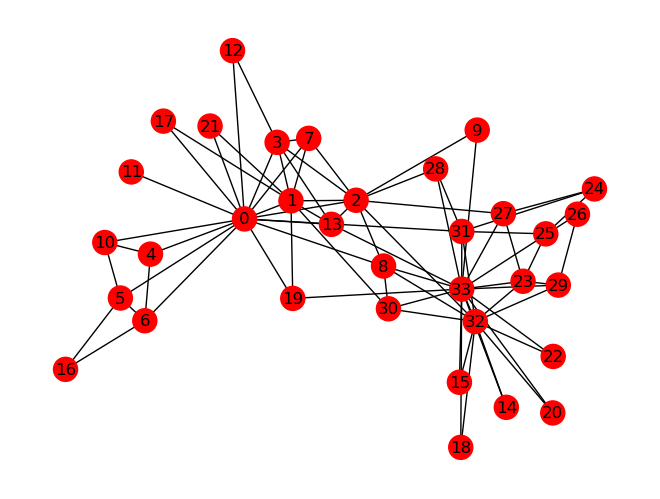

In [8]:
#CODE HERE
degree = dict(G.degree())
u = max(degree,key=degree.get)
v = min(degree,key=degree.get)

colors = []
for v in G.nodes:
    if v == u or v == v:
        colors.append('red')
    else:
        colors.append('green')

nx.draw(G, with_labels=True, node_color=colors)
plt.show()

3) Vẽ cây DFS tạo thành bằng cách duyệt graph từ đỉnh $x$, trong đó $x$ là tổng ba chữ số cuối trong MSSV của anh/chị. Một sinh viên cho rằng: "nếu đỉnh $y$ có cạnh nối với $x$ thì nhờ DFS chắc chắn sẽ được thăm sớm hơn các đỉnh không có cạnh nối với $x$", hỏi bạn này nhận xét đúng hay sai? Vì sao?

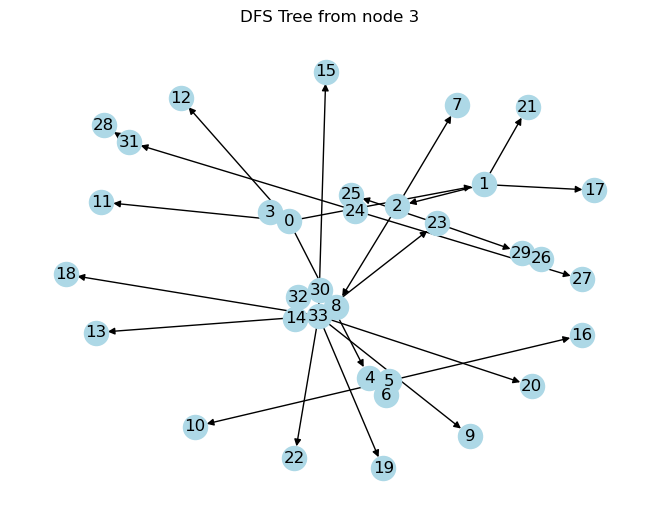

In [9]:
#CODE HERE
x = 3
dfs_tree = nx.dfs_tree(G, source=x)

# Vẽ cây DFS
pos = nx.spring_layout(dfs_tree, seed=42)
nx.draw(dfs_tree, pos, with_labels=True, node_color='lightblue')
plt.title(f"DFS Tree from node {x}")
plt.show()

sai vì DFS đi sâu theo 1 nhánh trước, không ưu tiên toàn bộ neighbor

### Bài 2. (2.0 = 1 + 1 đ) Trong BA chọn HAI:

1) Cho graph $G$ được mô tả bởi thông tin bên dưới. Tính giá trị của hệ số trung tâm closeness của đỉnh $4$ bằng 2 cách: dùng thư viện và tính toán trực tiếp.

In [10]:
G_sample1 = {
  '1' : ['2', '3'],
  '2' : ['1', '3'],
  '3' : ['1', '2', '4'],
  '4' : ['3', '5'],
  '5' : ['4', '6'],
  '6' : ['5']
}

In [14]:
#CODE HERE
#cách 1:
G = nx.Graph(G_sample1)
c1 = nx.closeness_centrality(G,'4')
print('closness thư viện = ',c1)

closness thư viện =  0.625


In [17]:
"""
n = 6 đỉnh
tổng d(4,v) =1 +1 +2 + 2 + 2 =8
=>  c = (6-1)/8 = """
c = (6-1)/8
print('cloness tính tay: ',c)

cloness tính tay:  0.625


2) Một graph đơn vô hướng có $12$ đỉnh với thông tin như sau: đỉnh $1$ nối với các đỉnh $2,3,4,5$, còn đỉnh $2$ nối với các đỉnh $1,7,8,9,10,11,12$. Hỏi tập độc lập lớn nhất của graph này có kích thước là bao nhiêu? Giải thích và in ra một ví dụ ứng với kích thước tìm được.

In [18]:
#CODE HERE

from itertools import combinations
G = nx.Graph()
G.add_edges_from([
    (1,2),(1,3),(1,4),(1,5),
    (2,7),(2,8),(2,9),(2,10),(2,11),(2,12)
])
# Thêm đủ 12 đỉnh (nếu thiếu)
G.add_nodes_from(range(1,13))

# Hàm kiểm tra tập độc lập
def is_independent_set(G, nodes):
    for u in nodes:
        for v in nodes:
            if u != v and G.has_edge(u, v):
                return False
    return True

# Tìm tập độc lập lớn nhất (brute force)
nodes = list(G.nodes)
max_set = []

for r in range(1, len(nodes)+1):
    for subset in combinations(nodes, r):
        if is_independent_set(G, subset):
            if len(subset) > len(max_set):
                max_set = subset

print("Kích thước lớn nhất =", len(max_set))
print("Một tập độc lập lớn nhất:", max_set)

Kích thước lớn nhất = 10
Một tập độc lập lớn nhất: (3, 4, 5, 7, 8, 9, 10, 11, 12, 6)


3) Một graph đều (regular) có $20$ đỉnh thì số cạnh có thể có là bao nhiêu? Vì sao?

In [25]:
#CODE HERE
"""
20 đỉnh mà mỗi đỉnh có bậc = k <= 2
do đó tổng bậc bậc = 20k
theo nguyên lý bắt tay, tổng bậc = 2m
=> m = 10k
"""
n = []
for x in range(20):
    n.append(x)
m = []
for i in n:
    m.append(10*i)

print('do đó số cạnh có thể có là: ',m)


do đó số cạnh có thể có là:  [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190]


### Bài 3. (2.5 = 1 + 1.5đ)

Sinh ngẫu nhiên một graph đơn, vô hướng, có tất cả $27$ đỉnh $100$ cạnh có trọng số nguyên thuộc miền $[-24,24]$ và liên thông (nếu graph không liên thông, anh/chị thực hiện sinh ngẫu nhiên tiếp cho đến khi nào liên thông thì thôi). Từ đó, thực hiện các yêu cầu sau:

1) Vẽ cây khung nhỏ nhất của graph dựa trên một trong hai thuật toán Prim / Kruskal, từ đó tính tổng trọng số nhỏ nhất đó. Hãy nêu ứng dụng của thuật toán tìm cây khung trong thực tế.

Tổng trọng số cây khung nhỏ nhất: -444


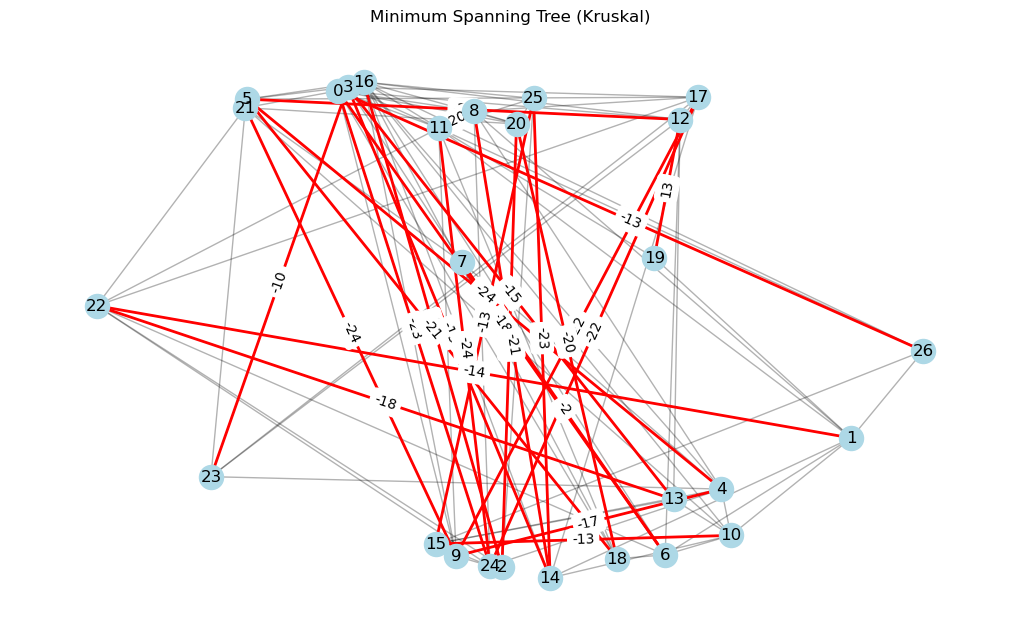

In [33]:
#COimport networkx as nx
import random

# Sinh graph đến khi liên thông
while True:
    G = nx.gnm_random_graph(27, 100)  
    
    if nx.is_connected(G):
        break

# Gán trọng số [-24, 24]
for u, v in G.edges():
    G[u][v]['weight'] = random.randint(-24, 24)

T = nx.minimum_spanning_tree(G, algorithm='kruskal')

# Tổng trọng số
total_weight = sum(data['weight'] for u, v, data in T.edges(data=True))

print("Tổng trọng số cây khung nhỏ nhất:", total_weight)

pos = nx.spring_layout(G, seed=42)

plt.figure(figsize=(10,6))

# vẽ graph gốc (mờ)
nx.draw(G, pos, node_size=100, alpha=0.3)

# vẽ MST (đậm)
nx.draw(T, pos, with_labels=True, node_color='lightblue', edge_color='red', width=2)

# vẽ trọng số trên cạnh MST
edge_labels = nx.get_edge_attributes(T, 'weight')
nx.draw_networkx_edge_labels(T, pos, edge_labels=edge_labels)

plt.title("Minimum Spanning Tree (Kruskal)")
plt.show()

ứng dụng:
- Thiết kế mạng, đảm bảo chi phí nhỏ và liên thông toàn bộ
- xây dựng hệ thống điện với việc kết nối các trạm điện với chi phí nhỏ
- thiết kế đường giao thông
- clustering (phân cụm, phát hiện cấu trúc nhóm)

2) Sử dụng hàm negative_edge_cycle trong thư viện networkx để xác định chu trình âm trong graph này:
- Nếu có chu trình âm thì in các đỉnh đó ra.
- Nếu không có chu trình âm thì sử dụng thuật toán Dijkstra để tính đường đi ngắn nhất giữa hai đỉnh có chỉ số là $a*b$ và $a+b$, trong đó $a$, $b$ là chữ số lớn nhất và nhỏ nhất (khác $0$) trong MSSV của anh/chị.

Hỏi cơ sở lý thuyết của thư viện đó là dựa trên thuật toán nào? 

In [34]:
#CODE HERE
# Kiểm tra có chu trình âm không
has_neg_cycle = nx.negative_edge_cycle(G, weight='weight')

if has_neg_cycle:
    print("Graph có chu trình âm")
    
    # lấy chu trình âm
    cycle = nx.find_negative_cycle(G, source=0, weight='weight')
    print("Chu trình âm:", cycle)

else:
    print("Graph không có chu trình âm")

Graph có chu trình âm
Chu trình âm: [0, 16, 0]


In [35]:
"""
nếu k có
mssv = "23715111"

digits = [int(x) for x in mssv if x != '0']
a = max(digits)
b = min(digits)

start = a * b
end = a + b
"""

'\nnếu k có\nmssv = "23715111"\n\ndigits = [int(x) for x in mssv if x != \'0\']\na = max(digits)\nb = min(digits)\n\nstart = a * b\nend = a + b\n'

In [37]:

"""path = nx.dijkstra_path(G, start, end, weight='weight')
dist = nx.dijkstra_path_length(G, start, end, weight='weight')

print("Đường đi ngắn nhất:", path)
print("Độ dài:", dist)
"""

'path = nx.dijkstra_path(G, start, end, weight=\'weight\')\ndist = nx.dijkstra_path_length(G, start, end, weight=\'weight\')\n\nprint("Đường đi ngắn nhất:", path)\nprint("Độ dài:", dist)\n'

Thuật toán Bellman-Ford:

Cho phép cạnh có trọng số âm

Sau n−1 lần relax, nếu vẫn cải thiện được → có chu trình âm

### Bài 4. (2.0 = 1+1đ)

Mạng lưới thông tin của các tên khủng bố được cho trong dữ liệu terrorist, gồm các file terrorist.pairs, terrorist.names, trong đó liên hệ của họ được mô tả bởi các cạnh có hướng. Hãy thực hiện các yêu cầu sau:

0) Đọc dữ liệu về tên và các cặp khủng bố có liên hệ nhau, in danh sách $10$ cặp tên đầu tiên của các tên khủng bố (đã có code tham khảo nên SV chỉ cần chạy code). 

1) Chuyển đổi dữ liệu sang DiGraph và vẽ graph này ra.

2) Thực hiện thuật toán pagerank, lấy hằng số $\alpha = 0.85$, in ra ma trận khởi tạo và bảng sắp thứ tự tên của các tên khủng bố cùng rank của họ (đã có code tham khảo). Hỏi hằng số $alpha$ này dùng để làm gì?

In [41]:
# anh/chị chỉ cần chạy code này để đọc dữ liệu
edge_list = np.loadtxt('terrorist.pairs', dtype=str)
node_name_dict = dict(np.loadtxt('terrorist.names', dtype=str))
edge_list = [(node_name_dict[source], node_name_dict[target]) for source, target in edge_list]
edge_list[:10]

[('Samir_Kashk', 'Essid_Sami_Ben_Khemais'),
 ('Madjid_Sahoune', 'Essid_Sami_Ben_Khemais'),
 ('Fahid_al_Shakri', 'Essid_Sami_Ben_Khemais'),
 ('Lased_Ben_Heni', 'Essid_Sami_Ben_Khemais'),
 ('Lased_Ben_Heni', 'Mohamed_Bensakhria'),
 ('Essid_Sami_Ben_Khemais', 'Samir_Kashk'),
 ('Essid_Sami_Ben_Khemais', 'Madjid_Sahoune'),
 ('Essid_Sami_Ben_Khemais', 'Fahid_al_Shakri'),
 ('Essid_Sami_Ben_Khemais', 'Lased_Ben_Heni'),
 ('Essid_Sami_Ben_Khemais', 'Seifallah_ben_Hassine')]

DiGraph named 'terrorist network 911' with 62 nodes and 304 edges
Số đỉnh: 62
Số cạnh: 304


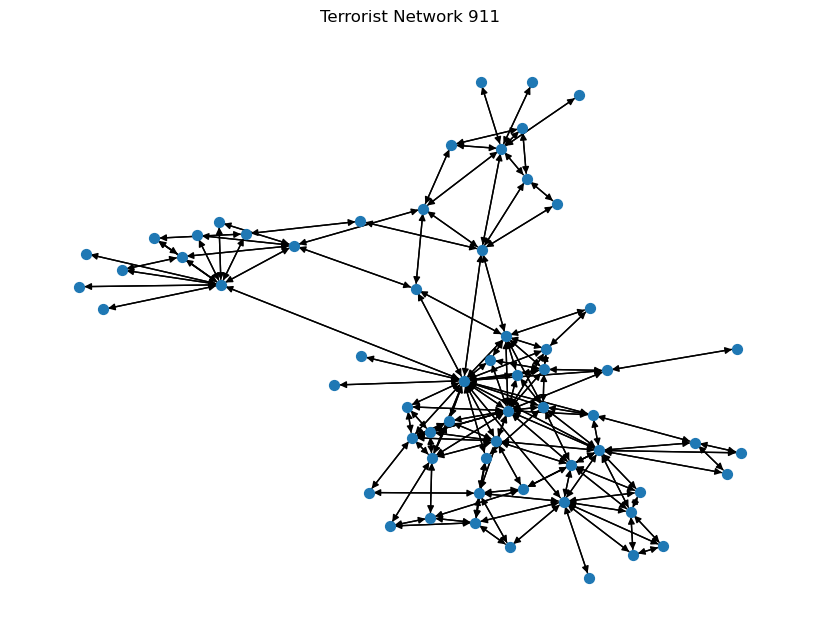

In [44]:
# anh/chị tạo graph có hướng tên là "terrorist network 911" rồi import thông tin cạnh từ edge_list
G = nx.DiGraph(name="terrorist network 911")
G.add_edges_from(edge_list)
# sau đó hiển thị tất cả thông tin của graph này ra, sử dụng hàm nx.info(...)
#print(nx.info(G)) python mới đã bị xóa rồi
print(G)
print("Số đỉnh:", G.number_of_nodes())
print("Số cạnh:", G.number_of_edges())
# cuối cùng vẽ graph này ra
# CODE HERE
# Vẽ graph
plt.figure(figsize=(8,6))
pos = nx.spring_layout(G, seed=42)

nx.draw(G, pos, node_size=50, arrows=True)
plt.title("Terrorist Network 911")
plt.show()

In [47]:
# điền vào chỗ trống để thực hiện thuật toán Page Rank và in ra ma trận khởi tạo
print(nx.google_matrix(G,alpha=0.85))
page_rank = nx.pagerank(G,alpha = 0.85)

[[0.00241935 0.85241935 0.00241935 ... 0.00241935 0.00241935 0.00241935]
 [0.07969208 0.00241935 0.07969208 ... 0.00241935 0.00241935 0.00241935]
 [0.00241935 0.85241935 0.00241935 ... 0.00241935 0.00241935 0.00241935]
 ...
 [0.00241935 0.00241935 0.00241935 ... 0.00241935 0.28575269 0.00241935]
 [0.00241935 0.00241935 0.00241935 ... 0.28575269 0.00241935 0.00241935]
 [0.00241935 0.00241935 0.00241935 ... 0.00241935 0.00241935 0.00241935]]


In [49]:
# anh/chị chỉ cần chạy code này để in ra thứ hạng các tên khủng bố
import pandas as pd
pr_df = pd.DataFrame([{'name': k, 'value': v} for k, v in page_rank.items()])
pr_df.head()

,name,value
0,Samir_Kashk,0.006114
1,Essid_Sami_Ben_Khemais,0.047815
2,Madjid_Sahoune,0.006114
3,Fahid_al_Shakri,0.006114
4,Lased_Ben_Heni,0.009873


In [50]:
# anh/chị chỉ cần chạy code này để in ra top 10 dựa theo kết quả làm được ở trên
pr_df.sort_values('value', ascending=False).head(10)

,name,value
11,Mohamed_Atta,0.060755
1,Essid_Sami_Ben_Khemais,0.047815
31,Marwan_Al-Shehhi,0.044991
17,Djamal_Beghal,0.036374
43,Hani_Hanjour,0.035418
44,Nawaf_Alhazmi,0.032473
24,Ramzi_Bin_al-Shibh,0.027930
15,Zacarias_Moussaoui,0.026033
9,Tarek_Maaroufi,0.024306
30,Ziad_Jarrah,0.023493


In [51]:
# Trả lời câu hỏi: hằng số alpha dùng để làm gì?
print("hằng số alpha là xác xuất tiếp tục đi theo các liên kết trong grapth")

hằng số alpha là xác xuất tiếp tục đi theo các liên kết trong grapth


### Bài 5. (0.5 điểm)

Tài có $8$ người bạn sống ở $8$ địa điểm khác nhau trong thành phố IUH, có $7$ con đường đi hai chiều nối trực tiếp giữa $7$ cặp địa chỉ nào đó, thú vị là mỗi con đường có độ dài đúng $1km$. Biết rằng nếu xuất phát từ một địa điểm bất kỳ, Tài đều có thể đi được đến tất cả các địa điểm khác thông qua các con đường trên. 

Vào một ngày nắng đẹp, Tài đi Grab đến nhà của Phú, một người bạn trong số đó rồi cùng Phú đi bộ để thăm hết các bạn kia. Biết rằng cặp đôi này rất đam mê thuật toán, đặc biệt là lý thuyết khai phá đồ thị nên sẽ chọn ra cách đi tốt nhất có thể. Kết quả là hai bạn đã phải đi bộ tổng cộng $12km$ để thăm được hết nhà của các bạn còn lại, tất nhiên là chỉ được đi trên các con đường có sẵn (một nhà có thể được đi qua nhiều lần). Anh/chị hãy thử dùng networkx để vẽ bản đồ mô tả chỗ ở của $8$ bạn của Tài nhé (trong đó có chỉ rõ nhà của Phú ở đâu).

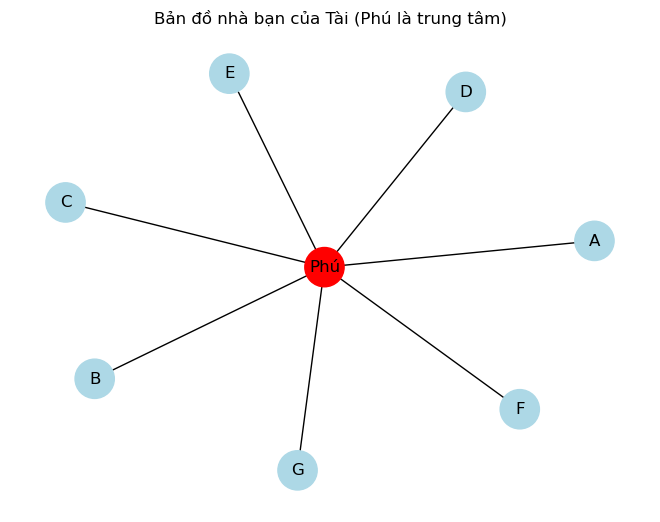

In [38]:
#CODE HERE
import networkx as nx
import matplotlib.pyplot as plt

# Tạo graph dạng star (1 trung tâm + 7 lá)
G = nx.star_graph(7)  # node 0 là trung tâm
labels = {
    0: "Phú",
    1: "A", 2: "B", 3: "C", 4: "D",
    5: "E", 6: "F", 7: "G"
}

# Màu node
colors = ['red' if node == 0 else 'lightblue' for node in G.nodes]

# Vẽ
pos = nx.spring_layout(G, seed=42)

nx.draw(G, pos, with_labels=True, labels=labels,
        node_color=colors, node_size=800)

plt.title("Bản đồ nhà bạn của Tài (Phú là trung tâm)")
plt.show()